# Validation du modèle final — Prédiction du Churn Client

## Objectif
Vérifier que le modèle Random Forest optimisé (déjà entraîné et sauvegardé lors de la phase de modélisation) généralise bien sur des données jamais vues, via une validation croisée et un test final. Contrairement au notebook de modélisation, on ne compare plus plusieurs algorithmes ici : on **confirme la fiabilité** du modèle déjà choisi, avant une éventuelle mise en production.

## Sommaire
1. Chargement des données et du modèle final
2. Validation croisée (stabilité du modèle)
3. Évaluation finale sur le test set
4. Comparaison visuelle et conclusion


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

## 2. Chargement des données et du modèle final

**Remarque** — On ne recharge pas `telco_churn_cleaned.csv` (qui n'existe plus dans le pipeline corrigé) et on ne refait pas de `train_test_split` : les données sont déjà séparées (`telco_churn_train.csv` / `telco_churn_test.csv`) et le modèle final est déjà entraîné et optimisé — on le charge directement au lieu de le recréer avec des paramètres codés en dur, pour garantir qu'on valide exactement le modèle retenu, pas une reconstruction approximative.

In [2]:
def load_train_test(train_path: str, test_path: str, target_col: str = 'Churn'):
    """Charge les jeux train/test déjà préparés par le pipeline de données."""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    print(f"Train : {X_train.shape} | Test : {X_test.shape}")
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_train_test(
    '../Data/processed/telco_churn_train.csv',
    '../Data/processed/telco_churn_test.csv'
)

Train : (5634, 30) | Test : (1409, 30)


In [3]:
def load_final_model(path: str):
    """Charge le modèle final déjà entraîné et optimisé (pas de ré-entraînement ici)."""
    model = joblib.load(path)
    print("Modèle final chargé :", model)
    return model


model_final = load_final_model('../models/best_model.joblib')

Modèle final chargé : RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)


## 3. Validation croisée (stabilité du modèle)

La validation croisée découpe le **train set** en 5 parties (`cv=5`). Le modèle s'entraîne et s'évalue 5 fois, sur des parties différentes à chaque fois. Ça permet de vérifier que le modèle n'a pas eu de "chance" avec un seul découpage particulier — un score isolé pourrait être optimiste ou pessimiste selon le hasard du split.

In [4]:
def cross_validate_model(model, X_train, y_train, cv: int = 5, scoring: str = 'roc_auc'):
    """
    Validation croisée stratifiée : préserve la proportion de churn dans
    chaque partie, cohérent avec le split stratifié fait en amont.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring=scoring)

    print(f"Scores AUC sur {cv} découpages différents :", scores.round(3))
    print(f"Moyenne : {scores.mean():.3f} | Écart-type : {scores.std():.3f}")
    return scores


cv_scores = cross_validate_model(model_final, X_train, y_train)

Scores AUC sur 5 découpages différents : [0.84  0.829 0.839 0.855 0.856]
Moyenne : 0.844 | Écart-type : 0.010


**Lecture** — Un **écart-type faible** (proche de 0) signifie que le modèle obtient un score similaire quel que soit le découpage — signe de **stabilité**. Un écart-type élevé indiquerait que la performance dépend beaucoup du hasard du split, donc un modèle moins fiable à généraliser.

## 4. Évaluation finale sur le test set

In [5]:
def evaluate_on_test(model, X_test, y_test):
    """
    Vérification finale sur le vrai jeu de test — des données que le modèle
    n'a jamais vues, ni pendant l'entraînement, ni pendant la validation croisée.
    """
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC sur test : {auc:.3f}")
    return y_pred, auc


y_pred_final, auc_test = evaluate_on_test(model_final, X_test, y_test)

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC sur test : 0.842


**Lecture** — Ce chiffre est la mesure la plus honnête de la performance réelle du modèle : le test set n'a jamais influencé ni l'entraînement, ni le choix des hyperparamètres, ni la validation croisée. C'est la meilleure estimation de ce à quoi s'attendre sur de vrais nouveaux clients.

## 5. Comparaison visuelle et conclusion

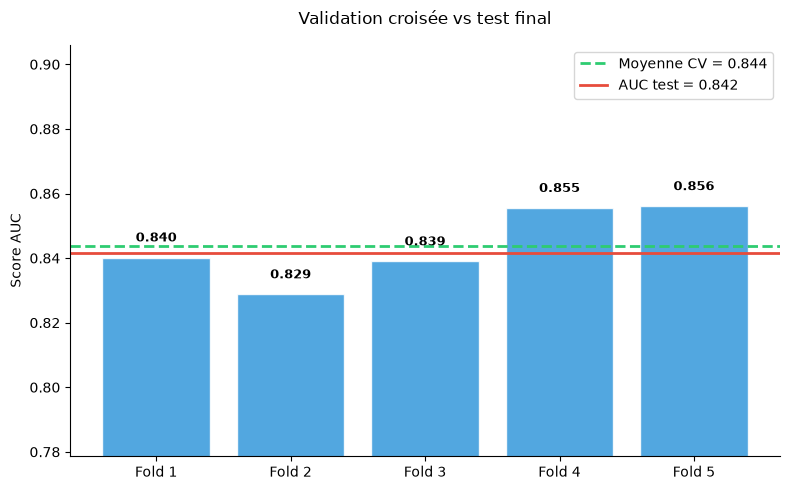

In [6]:
def plot_cv_vs_test(cv_scores, auc_test):
    """
    Compare visuellement les scores de validation croisée (5 barres)
    au score final sur le test set (ligne horizontale), pour repérer
    en un coup d'œil si le test set est cohérent avec la validation croisée.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    folds = [f'Fold {i+1}' for i in range(len(cv_scores))]

    bars = ax.bar(folds, cv_scores, color='#3498db', edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, cv_scores):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

    ax.axhline(cv_scores.mean(), color='#2ecc71', linestyle='--', linewidth=2,
               label=f'Moyenne CV = {cv_scores.mean():.3f}')
    ax.axhline(auc_test, color='#e74c3c', linestyle='-', linewidth=2,
               label=f'AUC test = {auc_test:.3f}')

    ax.set_ylabel('Score AUC')
    ax.set_title('Validation croisée vs test final', pad=15)
    ax.set_ylim(min(min(cv_scores), auc_test) - 0.05, max(max(cv_scores), auc_test) + 0.05)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_cv_vs_test(cv_scores, auc_test)

**Lecture** — Si la ligne rouge (test) est proche de la ligne verte (moyenne de validation croisée), le modèle se comporte de façon cohérente sur des données complètement nouvelles — pas de signe de surapprentissage. Un écart important entre les deux serait un signal d'alerte (le modèle performerait différemment sur le test que sur le train, donc moins fiable en production).

## Conclusion

**Ce que cette validation démontre :**
- La validation croisée sur plusieurs découpages confirme (ou infirme) la stabilité du modèle, indépendamment du hasard d'un split particulier.
- Le score sur le test final, jamais vu à aucune étape précédente, donne l'estimation la plus honnête de la performance réelle.
- Un écart faible entre validation croisée et test final indique que le modèle **généralise correctement**, sans surapprentissage.

**Décision** — Si les résultats ci-dessus sont cohérents et stables, le modèle chargé depuis `../models/best_model.joblib` peut être considéré comme fiable pour une mise en production ou une intégration dans un outil de scoring client.